# Lecture 13a: Automated Hyperparameter Tuning with GridSearchCV

**Status: Mandatory reading.**

In lectures 10-12 you tuned models **one hyperparameter at a time, by hand, on a single fixed
train/test split** — try `k=3`, then `k=5`, eyeball the accuracy, repeat. That does not scale:
real models have several hyperparameters at once, and a single split is a noisy judge. This
notebook automates the search with `GridSearchCV` and `RandomizedSearchCV`, scoring every
candidate with **k-fold cross-validation** so the winner is chosen reliably, not by luck of one split.

Three named industry uses (all MLOps-flavoured):

- **Nightly automated re-tuning** — fraud-detection teams re-run hyperparameter search on fresh
  data each night as fraud patterns drift, so the deployed model stays calibrated with no human in the loop.
- **Leakage-free preprocessing shipped as one artifact** — credit-scoring teams bundle
  scaler + encoder + model so production preprocessing exactly matches training (covered fully in `lec_13b`).
- **Experiment tracking + model registry for governance** — healthcare ML teams log every tuning
  run and gate champion/challenger promotions for audit (covered in `lec_13c` / `lec_13d`).

Career framing: automating model selection — building search spaces, reading cross-validation
results, and picking the winner — is the **daily work of an ML / MLOps engineer**.

**What this notebook covers:**

- Why a single validation split is noisy, and how **k-fold cross-validation** fixes it.
- `GridSearchCV`: exhaustive search over a grid, reading `best_params_`, `best_score_`, `best_estimator_`, `cv_results_`.
- Computing **grid size** (candidates x folds) and watching it explode.
- `RandomizedSearchCV`: a fixed-budget alternative for large spaces.
- Choosing the **scoring metric** (`accuracy` vs `recall` vs `roc_auc`) and why it changes the winner.
- Tuning **two hyperparameters at once**, visualising the search, and the **timing** cost of going exhaustive.
- Refitting `best_estimator_` and reporting the **honest test-set** score.
- Pitfalls: leakage from preprocessing outside CV, and never tuning on the test set.

Forward pointer: `lec_13b` wraps the preprocessing **inside** a `Pipeline` so the scaler and encoder
are fit on the training fold only — the leakage fix this notebook foreshadows.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV,
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

RANDOM_STATE = 42

## The data: heart-disease screening

We reuse the heart-disease dataset that runs through all of Lecture 13. Each row is a patient; the
target `Heart Disease` is `Presence` / `Absence`. The full file is large, so we **sample 1500 rows**
to keep every search under a few seconds — the teaching points are identical at full size.

In [2]:
# Heart-disease dataset (committed alongside this notebook). 630k rows -> sample for fast teaching.
df = (
    pd.read_csv("predict_heart_disease_train.csv")
    .drop(columns=["id"])
    .sample(n=100000, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

# Binary target: 1 = heart disease present, 0 = absent
y = (df["Heart Disease"] == "Presence").astype(int)
X = df.drop(columns=["Heart Disease"])

# Continuous numeric features -> scale; integer-coded categorical features -> one-hot encode
NUMERIC = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]
CATEGORICAL = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
               "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]

print("Shape:", X.shape)
print("Target balance:\n", y.value_counts(normalize=True).round(2))

Shape: (100000, 13)
Target balance:
 Heart Disease
0    0.55
1    0.45
Name: proportion, dtype: float64


We split off a **test set we will not touch until the very end**. The search only ever sees the
training set; the test set is the final, honest judge. We pass `stratify=y` so both sides keep the
~57% absent / 43% present balance.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y,
)
print("Train rows:", len(X_train), " Test rows:", len(X_test))

Train rows: 75000  Test rows: 25000


## Motivation: is `C=1` the best choice?

`LogisticRegression` has a regularisation strength `C` (default `1.0`). Larger `C` = weaker
regularisation = the model fits the training data harder. We have **no reason to believe the default
is best for this dataset.** Let's fit one model with the default and look at its accuracy.

(For now we scale the numeric columns crudely outside cross-validation just to get a model running —
this is exactly the leakage trap we fix in the Pitfalls section and in `lec_13b`.)

In [4]:
# Quick-and-dirty: scale only the numeric block so LogisticRegression converges nicely.
scaler = StandardScaler().fit(X_train[NUMERIC])
X_train_num_scaled = X_train.copy()
X_test_num_scaled = X_test.copy()
X_train_num_scaled[NUMERIC] = scaler.transform(X_train[NUMERIC])
X_test_num_scaled[NUMERIC] = scaler.transform(X_test[NUMERIC])

default_model = LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE)
default_model.fit(X_train_num_scaled, y_train)
print("Test accuracy with default C=1.0:", round(default_model.score(X_test_num_scaled, y_test), 3))

Test accuracy with default C=1.0: 0.883


## Why cross-validation beats a single validation split

If we judged `C` on **one** held-out validation slice, the winner might just be the value that
happened to suit that one slice — a noisy verdict. **k-fold cross-validation** removes that luck:

- Split the training data into `k` equal **folds** (here `k=5`).
- Train on `k-1` folds, validate on the held-out fold; rotate so **every row is validated exactly once**.
- The score is the **average over the `k` folds** — far less variance than any single split.

`cross_val_score` does this for us. Below, each of the 5 numbers is one fold's accuracy; their mean
is the reliable estimate.

In [5]:
cv_scores = cross_val_score(
    LogisticRegression(C=1.0, max_iter=2000, random_state=RANDOM_STATE),
    X_train_num_scaled, y_train, cv=5,
)
print("Per-fold accuracy:", np.round(cv_scores, 3))
print("Mean CV accuracy:", round(cv_scores.mean(), 3), "+/-", round(cv_scores.std(), 3))

Per-fold accuracy: [0.884 0.882 0.881 0.878 0.883]
Mean CV accuracy: 0.882 +/- 0.002


## `GridSearchCV`: search a grid automatically

`cross_val_score` scores **one** setting. `GridSearchCV` runs that cross-validation for **every**
combination in a grid you hand it, then keeps the best. We tune `C` over a handful of values.

The grid is a dictionary: `{"<param_name>": [list of values]}`. We pin `solver="lbfgs"` with
`penalty="l2"` — a valid, compatible pair (not every solver supports every penalty). After fitting,
`GridSearchCV` exposes:

- `best_params_` — the winning combination.
- `best_score_` — its mean cross-validation score.
- `best_estimator_` — a model already **refit on all of the training data** with those params.
- `cv_results_` — the full score table for every candidate.

In [6]:
param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],
    "penalty": ["l2"],
    "solver": ["lbfgs"],
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,   # use all CPU cores
)
grid.fit(X_train_num_scaled, y_train)

print("best_params_ :", grid.best_params_)
print("best_score_  :", round(grid.best_score_, 3))
print("best_estimator_:", grid.best_estimator_)

best_params_ : {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
best_score_  : 0.882
best_estimator_: LogisticRegression(max_iter=1000, penalty='l2', random_state=42)


`cv_results_` is a dictionary that turns straight into a tidy DataFrame. We pull out the mean
cross-validation score per candidate and sort best-first — this is exactly what you would scan to
understand *which* setting won and by how much.

In [7]:
results = pd.DataFrame(grid.cv_results_)

tidy = (
    results[["param_C", "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .reset_index(drop=True)
)
tidy

,param_C,mean_test_score,std_test_score,rank_test_score
0,1.00,0.881587,0.001912,1
1,10.00,0.881573,0.001949,2
2,100.00,0.881573,0.001949,2
3,0.10,0.881560,0.001947,4
4,0.01,0.881480,0.002144,5


## Choosing the scoring metric

Accuracy is not always the right target. For heart-disease screening the costly mistake is a
**false negative** — telling a sick patient they are healthy. The metric that punishes that is
**recall** (of the positive class): *of all truly sick patients, how many did we catch?*

- `GridSearchCV(..., scoring="recall")` makes the search optimise recall instead of accuracy.
- `scoring="roc_auc"` ranks settings by how well the model separates the two classes across all
  thresholds — a good threshold-free summary.
- The grid is identical; only the **scoring** changes. Sometimes that flips the winner; sometimes
  (as below) the same `C` still wins, but you now read its **recall** instead of its accuracy.

In [8]:
recall_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=param_grid,        # same C / penalty / solver grid as before
    cv=5,
    scoring="recall",             # optimise catch-the-sick, not overall accuracy
    n_jobs=-1,
)
recall_grid.fit(X_train_num_scaled, y_train)

print("Accuracy-optimised best_params_:", grid.best_params_)
print("Recall-optimised   best_params_:", recall_grid.best_params_)
print("Best mean CV recall            :", round(recall_grid.best_score_, 3))
# (Swap scoring=\"roc_auc\" above to rank by ranking quality instead.)

Accuracy-optimised best_params_: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Recall-optimised   best_params_: {'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'}
Best mean CV recall            : 0.855


In [9]:
# A third metric: roc_auc ranks settings by class separation across all thresholds.
roc_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=param_grid,        # same grid again
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
)
roc_grid.fit(X_train_num_scaled, y_train)
print("roc_auc-optimised best_params_:", roc_grid.best_params_)
print("Best mean CV roc_auc          :", round(roc_grid.best_score_, 3))

roc_auc-optimised best_params_: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best mean CV roc_auc          : 0.95


On this grid all three metrics happen to crown the **same** `C = 1.0` — varying `C` alone barely
moves recall, so the metric only changes *which number you report*, not the winner. That is itself a
lesson: **changing the metric is not enough if no candidate in the grid actually trades accuracy for
recall.** To genuinely catch more sick patients we need a hyperparameter that shifts the decision
boundary — `class_weight`, which the next section adds to the grid. **Pick the metric that matches
the real-world cost of each error, and give the grid a knob that can act on it.**

A quick check confirms it. The accuracy-optimised and recall-optimised models are the **same**
estimator here (both `C = 1.0`), so they miss exactly the same sick patients on the held-out test
set. The metric label alone bought us nothing — which is precisely why the next section widens the
grid with `class_weight`.

In [10]:
acc_winner = grid.best_estimator_                       # accuracy-optimised
rec_winner = recall_grid.best_estimator_               # recall-optimised (already refit on all train data)

sick = (y_test == 1)
missed_by_acc = ((acc_winner.predict(X_test_num_scaled) == 0) & sick).sum()
missed_by_rec = ((rec_winner.predict(X_test_num_scaled) == 0) & sick).sum()

print("Truly sick patients in test set :", int(sick.sum()))
print("Missed by accuracy-optimised    :", int(missed_by_acc))
print("Missed by recall-optimised      :", int(missed_by_rec))

Truly sick patients in test set : 11216
Missed by accuracy-optimised    : 1613
Missed by recall-optimised      : 1613


## Tuning more than one hyperparameter

So far we varied one knob (`C`). Real tuning sweeps several at once. Here we cross `C` with
`class_weight`, which controls how hard the model is penalised for misclassifying the minority
(sick) class:

- `class_weight=None` — every patient weighted equally.
- `class_weight="balanced"` — the rarer class is up-weighted, nudging the model to catch more sick patients.

Two lists of lengths 5 and 2 give **5 x 2 = 10 candidates** — the count grows *multiplicatively*,
not additively.

In [11]:
two_param_grid = {
    "C": [0.01, 0.1, 1.0, 10.0, 100.0],   # 5 values
    "class_weight": [None, "balanced"],   # 2 values
}

n_candidates_2d = len(two_param_grid["C"]) * len(two_param_grid["class_weight"])
print("Candidates:", n_candidates_2d, "(= 5 x 2)")

two_param_search = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    param_grid=two_param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
)
two_param_search.fit(X_train_num_scaled, y_train)
print("best_params_:", two_param_search.best_params_)

Candidates: 10 (= 5 x 2)
best_params_: {'C': 1.0, 'class_weight': 'balanced'}


In [12]:
# Top-5 candidates from the 2-D grid, sorted by rank.
two_results = pd.DataFrame(two_param_search.cv_results_)
two_tidy = (
    two_results[["param_C", "param_class_weight",
                 "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
    .head(5)
    .reset_index(drop=True)
)
two_tidy

,param_C,param_class_weight,mean_test_score,std_test_score,rank_test_score
0,1.00,balanced,0.872418,0.002570,1
1,10.00,balanced,0.872418,0.002509,2
2,100.00,balanced,0.872418,0.002509,2
3,0.10,balanced,0.872181,0.002340,4
4,0.01,balanced,0.872032,0.002259,5


A grouped bar view of the 2-D grid makes the `class_weight` effect obvious: for each `C`, the
`balanced` bar sits where up-weighting the sick class helped recall, and `None` where it did not.

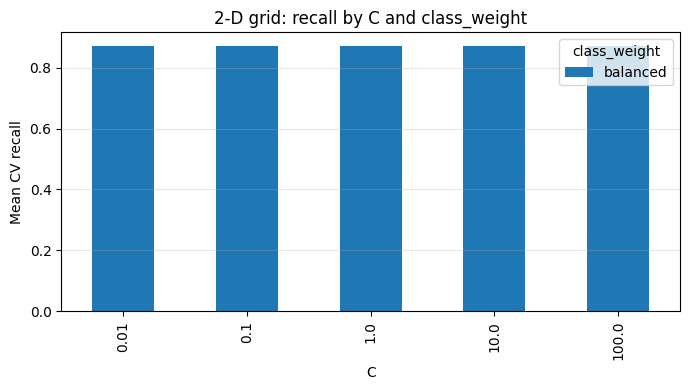

In [13]:
# Mean CV recall per (C, class_weight) cell, as a grouped bar chart.
pivot = two_results.pivot_table(
    index="param_C", columns="param_class_weight", values="mean_test_score"
)

ax = pivot.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("C")
ax.set_ylabel("Mean CV recall")
ax.set_title("2-D grid: recall by C and class_weight")
ax.legend(title="class_weight")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Visualising the search

A score table is precise but hard to read at a glance. Plotting the **mean CV score against the `C`
grid** (a validation-curve-style view) shows the sweet spot immediately: too small a `C` over-
regularises and underfits; too large adds nothing. We use the accuracy run from earlier.

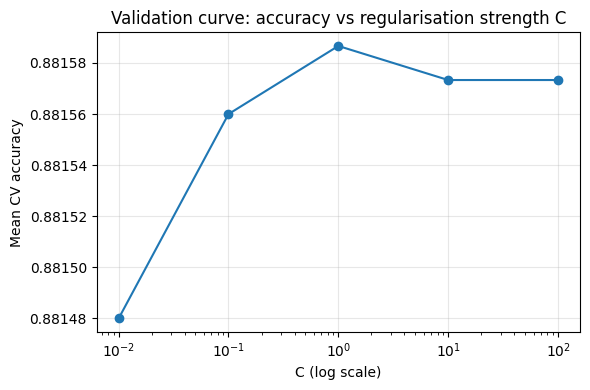

In [14]:
# Pull mean CV accuracy per C value from the earlier accuracy grid.
acc_results = pd.DataFrame(grid.cv_results_).sort_values("param_C")
c_values = acc_results["param_C"].astype(float)
mean_scores = acc_results["mean_test_score"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(c_values, mean_scores, marker="o")
ax.set_xscale("log")                    # C spans several orders of magnitude
ax.set_xlabel("C (log scale)")
ax.set_ylabel("Mean CV accuracy")
ax.set_title("Validation curve: accuracy vs regularisation strength C")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Grid size: the combinatorial explosion

The number of **candidates** is the product of the grid-list lengths. The total number of model
**fits** is `candidates x folds` — because each candidate is cross-validated. Add one more
hyperparameter and the count multiplies, not adds. Watch a 3-hyperparameter grid blow up.

In [15]:
big_grid = {
    "C":       [0.01, 0.1, 1.0, 10.0, 100.0],   # 5 values
    "penalty": ["l1", "l2"],                     # 2 values
    "solver":  ["liblinear", "saga"],            # 2 values
}

n_candidates = 1
for values in big_grid.values():
    n_candidates *= len(values)

folds = 5
print("Grid-list lengths :", [len(v) for v in big_grid.values()])
print("Candidates        :", n_candidates, "(= 5 x 2 x 2)")
print("Total model fits  :", n_candidates * folds, "(= candidates x folds)")

Grid-list lengths : [5, 2, 2]
Candidates        : 20 (= 5 x 2 x 2)
Total model fits  : 100 (= candidates x folds)


## `RandomizedSearchCV`: a fixed budget for large spaces

When the grid is large (or a hyperparameter is continuous), an exhaustive search is wasteful.
`RandomizedSearchCV` samples a **fixed number** of combinations (`n_iter`) from the space instead of
trying them all. We give it the same large space but a budget of only `n_iter=8`, seed it with
`random_state=RANDOM_STATE` for reproducibility, and compare wall-clock time and best score against
the exhaustive grid.

In [ ]:
# Exhaustive grid over the large space (the full 20 candidates x 5 folds = 100 fits).
exhaustive = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_grid=big_grid,
    cv=5, scoring="accuracy", n_jobs=-1,
)
t0 = time.perf_counter()
exhaustive.fit(X_train_num_scaled, y_train)
grid_time = time.perf_counter() - t0
print(f"GridSearchCV  : {n_candidates} candidates, best={exhaustive.best_score_:.3f}, time={grid_time:.2f}s")

GridSearchCV  : 20 candidates, best=0.882, time=6.79s


In [17]:
# Randomized search: sample only 8 of the 20 candidates.
random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    param_distributions=big_grid, n_iter=8, cv=5, scoring="accuracy",
    random_state=RANDOM_STATE, n_jobs=-1,
)
t0 = time.perf_counter()
random_search.fit(X_train_num_scaled, y_train)
rand_time = time.perf_counter() - t0
print(f"RandomizedSearchCV: 8 candidates, best={random_search.best_score_:.3f}, time={rand_time:.2f}s")

RandomizedSearchCV: 8 candidates, best=0.882, time=2.92s


**The rule:** use `GridSearchCV` for **small** grids (you can afford to try everything); switch to
`RandomizedSearchCV` when the grid is **large** — it finds a near-best setting for a fraction of the
fits. Here both land on essentially the same accuracy, but the randomized search did less work.

## Refit and evaluate on the held-out test set

`best_estimator_` is the winning model **already refit on all the training data**. We now score it
once on the test set we set aside at the start. This is the **honest** estimate: the test rows
played no part in choosing `C`, so this number is what we expect on genuinely new patients.

In [18]:
best_model = grid.best_estimator_                      # accuracy-optimised winner
y_pred = best_model.predict(X_test_num_scaled)

print("Held-out test accuracy:", round(best_model.score(X_test_num_scaled, y_test), 3))
print()
print(classification_report(y_test, y_pred, target_names=["Absence", "Presence"]))

Held-out test accuracy: 0.883

              precision    recall  f1-score   support

     Absence       0.89      0.91      0.90     13784
    Presence       0.88      0.86      0.87     11216

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



## A timing comparison: exhaustive vs randomized

We already ran both searches over the 20-candidate `big_grid` and timed each with
`time.perf_counter()`. Here is the head-to-head summary — exhaustive `GridSearchCV` tries all 20;
`RandomizedSearchCV` samples only 8. Both reach essentially the same best score, but the randomized
search does it in a fraction of the fits.

In [19]:
summary = pd.DataFrame(
    [
        ["GridSearchCV (exhaustive)", n_candidates, exhaustive.best_score_, grid_time],
        ["RandomizedSearchCV (n_iter=8)", 8, random_search.best_score_, rand_time],
    ],
    columns=["search", "candidates", "best_cv_score", "wall_time_s"],
).round({"best_cv_score": 3, "wall_time_s": 3})
summary

,search,candidates,best_cv_score,wall_time_s
0,GridSearchCV (exhaustive),20,0.882,6.793
1,RandomizedSearchCV (n_iter=8),8,0.882,2.920


**Pointer — nested cross-validation.** The test-set score above is honest because the test rows
never influenced the search. To *also* get an unbiased performance estimate of the whole search
procedure (search + refit) without holding out a single fixed test set, wrap the `GridSearchCV` in
an **outer** cross-validation loop — this is *nested CV*. It is more expensive and beyond this
lecture, but worth knowing the term exists.

## Pitfalls / when NOT to

- **Combinatorial cost.** Candidates = product of grid-list lengths; fits = candidates x folds. A
  few extra values per hyperparameter can turn seconds into hours. Prefer `RandomizedSearchCV` for big spaces.
- **Preprocessing outside cross-validation leaks.** We scaled with `StandardScaler().fit(X_train)`
  **before** the CV split, so every fold's "held-out" validation rows secretly influenced the scaler's
  mean and variance. That is **data leakage** — it inflates the CV score. The fix is to put the scaler
  and encoder **inside** a `Pipeline` so they are refit on each training fold only (this is exactly `lec_13b`).
- **Never select hyperparameters on the test set.** Tune with cross-validation on the **training**
  data; touch the test set **once**, at the very end, to report the honest final accuracy. Peeking at
  the test set during tuning makes your reported score a fantasy.
- **`n_jobs=-1` uses all cores.** It speeds up the search by running fits in parallel, but it will
  saturate your CPU. Set `n_jobs=1` if you need the machine responsive while a big search runs.

## Recap and what's next

- A single validation split is a **noisy** judge; **k-fold cross-validation** averages over folds so
  every row is validated once — a reliable score.
- `GridSearchCV` cross-validates **every** grid combination and hands you `best_params_`,
  `best_score_`, `best_estimator_`, and the full `cv_results_` table.
- Grid size explodes multiplicatively: **candidates x folds** fits. `RandomizedSearchCV` trades
  exhaustiveness for a fixed `n_iter` budget — the right tool once the grid is large.
- The **scoring metric** decides the winner: optimise `recall` (or `roc_auc`) when a false
  negative is the costly error, not blanket `accuracy`.
- Report the final number **once** on the held-out test set — the honest estimate.
- We **leaked** by scaling outside cross-validation. The honest fix is a `Pipeline`.

**Next — `lec_13b`:** chain the `ColumnTransformer` (scale + encode) and the estimator into one
`Pipeline`, so preprocessing is fit on the training fold only (leakage-free), then run `GridSearchCV`
over the whole pipeline across more than one classifier family.